In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Load dataset

nutrition_df = pd.read_csv("https://raw.githubusercontent.com/ekasaaa/analisis-dataset-gizi/refs/heads/main/dataset_nilai_gizi_cleaned_scaled(revisi2).csv", delimiter=";")
nutrition_df.head()

,name,energy_kcal,protein_g,fat_g,carbohydrate_g,sugar_g
0,Ikan sunu,0.058479532163742694,0.016916666666666667,0.16634146341463416,0.42071881606765327,0.052985
1,Soto pekalongan,0.000760233918128655,0.07833333333333334,0.024878048780487803,0.0063424947145877385,0.050746
2,Marie duo,0.008771929824561403,0.0008333333333333334,0.01707317073170732,0.029598308668076112,0.037313
3,Kaparende,0.000760233918128655,0.03166666666666667,0.012682926829268294,0.00507399577167019,0.014925
4,Kacang lebui / iris,0.2023391812865497,0.01375,0.007317073170731707,0.1408033826638478,0.000000


In [3]:
#Cek tipe data dan informasi lainnya
nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641 entries, 0 to 1640
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1641 non-null   object 
 1   energy_kcal     1641 non-null   object 
 2   protein_g       1641 non-null   object 
 3   fat_g           1641 non-null   object 
 4   carbohydrate_g  1641 non-null   object 
 5   sugar_g         1641 non-null   float64
dtypes: float64(1), object(5)
memory usage: 77.1+ KB


In [4]:
#Mengecek missing values pada dataset nutrition_df
nutrition_df.isna().sum()

name              0
energy_kcal       0
protein_g         0
fat_g             0
carbohydrate_g    0
sugar_g           0
dtype: int64

In [5]:
#Mengecek duplikasi tabel nutrition_df
print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


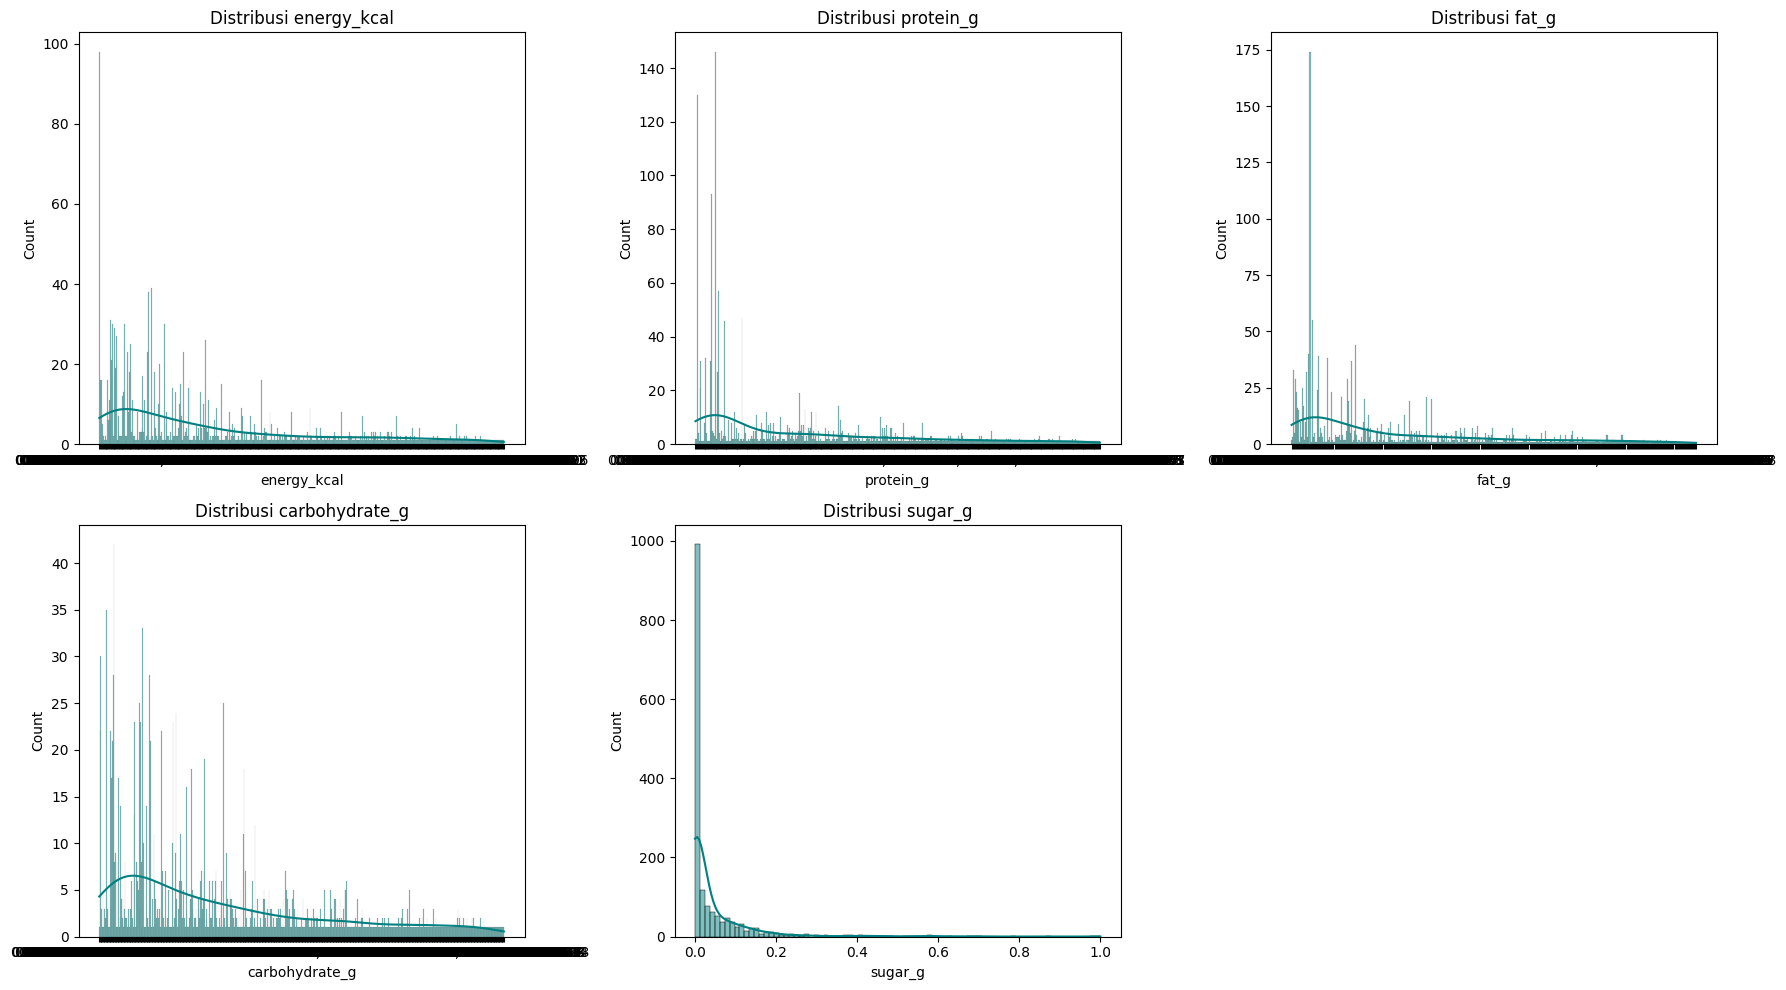

In [6]:
#Analisis 1: Distribusi Kandungan Gizi

#Daftar kolom nutrisi yang di analisis
nutrisi_cols = ['energy_kcal', 'protein_g', 'fat_g', 'carbohydrate_g', 'sugar_g']

plt.figure(figsize=(18, 10))
for i, col in enumerate(nutrisi_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(nutrition_df[col], kde=True, color='teal')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

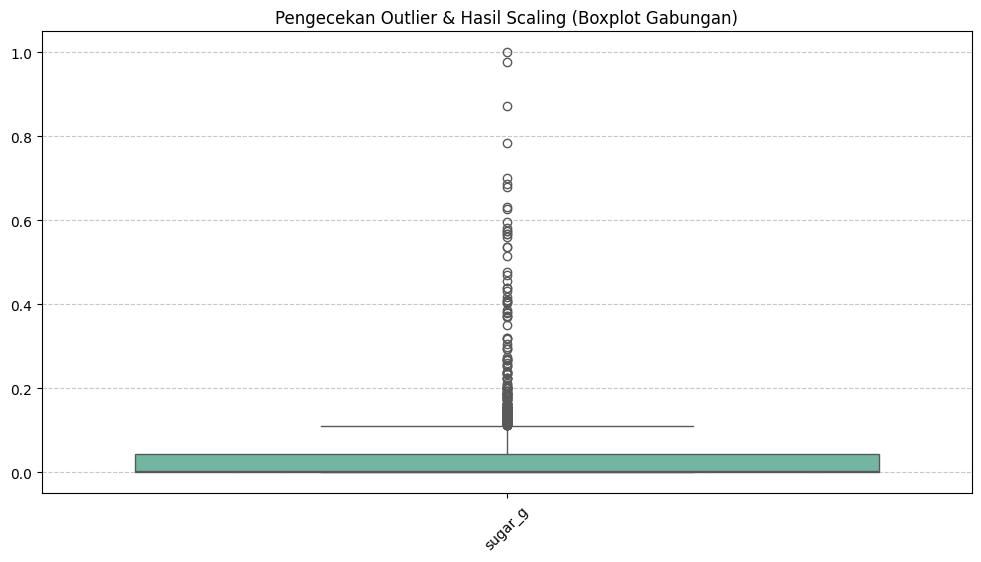

In [7]:
#Analisis 2: Kualitas Hasil Scaling

plt.figure(figsize=(12, 6))

# Boxplot gabungan untuk melihat rentang nilai setelah scaling
sns.boxplot(data=nutrition_df[nutrisi_cols], palette="Set2")
plt.title('Pengecekan Outlier & Hasil Scaling (Boxplot Gabungan)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

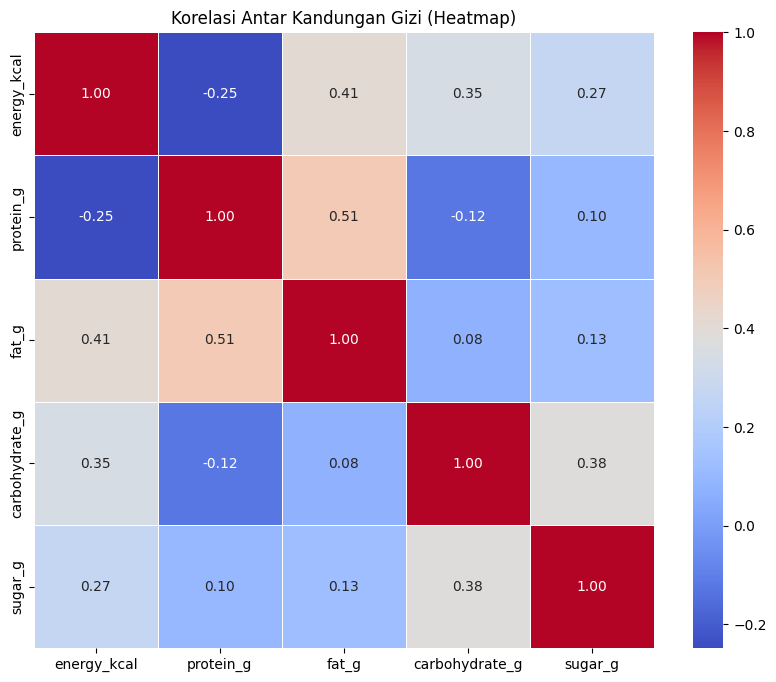

In [8]:
# Analisis 3: Hubungan Antar Nutrisi

plt.figure(figsize=(10, 8))

# Kita paksa kolom nutrisi jadi numerik, yang error bakal jadi NaN (kosong)
df_numeric = nutrition_df[nutrisi_cols].apply(pd.to_numeric, errors='coerce')

# Menghitung korelasi
correlation_matrix = df_numeric.corr()

# Membuat heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelasi Antar Kandungan Gizi (Heatmap)')
plt.show()

In [9]:
# Simpan hasil akhir EDA ke folder data
nutrition_df.to_csv('dataset_gizi_final.csv', index=False)